# Projet rêves

In [2]:
import pandas as pd

In [ ]:
# import dataset from hugging face

df = pd.read_parquet("hf://datasets/DReAMy-lib/DreamBank-dreams-en/data/train-00000-of-00001-24937aef854be1c9.parquet")

# ( source of the dataset : https://dreambank.net/)

In [ ]:
# useful links :

https://dreams.ucsc.edu/Coding/ # Hall/Van de Castle System of Quantitative Dream Content Analysis

In [8]:
df.describe()

,series,description,dreams,gender,year
count,22415,22415,22415,22415,22415
unique,69,69,22164,2,55
top,b,Barb Sanders,A young boy is curious about kissing. He wants...,female,1960-1997
freq,3114,3114,2,14429,3114


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22415 entries, 0 to 22414
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   series       22415 non-null  object
 1   description  22415 non-null  object
 2   dreams       22415 non-null  object
 3   gender       22415 non-null  object
 4   year         22415 non-null  object
dtypes: object(5)
memory usage: 875.7+ KB


In [ ]:
df.head(10)

,series,description,dreams,gender,year
0,david,David: teenage dreams,"I was in the Grammar School playground, and th...",male,1990-1999
1,david,David: teenage dreams,Funny dream last night. Kinda hard to remember...,male,1990-1999
2,david,David: teenage dreams,"Last night I had a dream I was in Payless, wea...",male,1990-1999
3,david,David: teenage dreams,"I was outside my house, at dusk, with Steve an...",male,1990-1999
4,david,David: teenage dreams,"I was in K-Mart, by some kind of loudspeaker. ...",male,1990-1999
5,david,David: teenage dreams,I drove the Buick to the DMV to get it insured.,male,1990-1999
6,david,David: teenage dreams,Our whole school went on this trip to Spain or...,male,1990-1999
7,david,David: teenage dreams,"It was nighttime, and cold; I could see my bre...",male,1990-1999
8,david,David: teenage dreams,For a while I dreamt I was having sex with Lis...,male,1990-1999
9,david,David: teenage dreams,There was this girl with long brown hair. She ...,male,1990-1999


In [43]:
df.shape

(22415, 7)

In [45]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape # 2 duplicated

(22413, 7)

In [ ]:
df['dreams'][0]

'I was in the Grammar School playground, and this time Angela had taken off to somewhere in the school. So I ran over to Julie and asked her if she knew where Angela was, and she said: "I can\'t tell you that." At first I thought she was just being a bitch about it. But then I asked her why. Then she sort of laughed and said: "I haven\'t seen her all day. Why don\'t you talk to her brother over there?" So then I walked over to the bus stop. I was greeted by a 7-foot-tall giant of a dork who said: "Who the hell are you?" I said: "I\'m David, have you seen Angela? He said, "Yeah, she\'s in the school building." I said, "Great," and started walking to the school. He stopped me, gave me a giant slab of masking tape rolled up to look like a joint the size of a cigar. He said, "first let\'s play some games." We both walked out into the street to a cone, then stood there until a truck came by. Then we\'d wait until the truck was a little bit away, then we\'d run into the bushes pretending to 

In [25]:
type(df['dreams'][0])

str

In [51]:
df['dreams'].isnull().any()
# df.isnull().any().sum()


False

In [ ]:
## series

df['series'].value_counts()

series
b            3114
kenneth      2021
elizabeth    1707
norman       1235
emma         1221
             ... 
tom            27
dahlia         24
mark           23
edna           19
ringo          16
Name: count, Length: 69, dtype: int64

In [41]:
df['series'].value_counts().shape

(69,)

In [ ]:
# more info on these series : https://dreambank.net/grid.cgi

In [33]:
# colonne year sous forme de plage parfois(1960-1997)
# extraire la première année mentionnée
# \d{4} cherche un groupe de 4 chiffres
df['clean_year'] = df['year'].str.extract(r'(\d{4})').astype(float)

In [35]:
df.head(10)

,series,description,dreams,gender,year,clean_year
0,david,David: teenage dreams,"I was in the Grammar School playground, and th...",male,1990-1999,1990.0
1,david,David: teenage dreams,Funny dream last night. Kinda hard to remember...,male,1990-1999,1990.0
2,david,David: teenage dreams,"Last night I had a dream I was in Payless, wea...",male,1990-1999,1990.0
3,david,David: teenage dreams,"I was outside my house, at dusk, with Steve an...",male,1990-1999,1990.0
4,david,David: teenage dreams,"I was in K-Mart, by some kind of loudspeaker. ...",male,1990-1999,1990.0
5,david,David: teenage dreams,I drove the Buick to the DMV to get it insured.,male,1990-1999,1990.0
6,david,David: teenage dreams,Our whole school went on this trip to Spain or...,male,1990-1999,1990.0
7,david,David: teenage dreams,"It was nighttime, and cold; I could see my bre...",male,1990-1999,1990.0
8,david,David: teenage dreams,For a while I dreamt I was having sex with Lis...,male,1990-1999,1990.0
9,david,David: teenage dreams,There was this girl with long brown hair. She ...,male,1990-1999,1990.0


In [36]:
# Calculer le nombre de mots par rêve
df['word_count'] = df['dreams'].apply(lambda x: len(str(x).split()))

In [37]:
df.head(10)

,series,description,dreams,gender,year,clean_year,word_count
0,david,David: teenage dreams,"I was in the Grammar School playground, and th...",male,1990-1999,1990.0,214
1,david,David: teenage dreams,Funny dream last night. Kinda hard to remember...,male,1990-1999,1990.0,115
2,david,David: teenage dreams,"Last night I had a dream I was in Payless, wea...",male,1990-1999,1990.0,38
3,david,David: teenage dreams,"I was outside my house, at dusk, with Steve an...",male,1990-1999,1990.0,98
4,david,David: teenage dreams,"I was in K-Mart, by some kind of loudspeaker. ...",male,1990-1999,1990.0,56
5,david,David: teenage dreams,I drove the Buick to the DMV to get it insured.,male,1990-1999,1990.0,11
6,david,David: teenage dreams,Our whole school went on this trip to Spain or...,male,1990-1999,1990.0,58
7,david,David: teenage dreams,"It was nighttime, and cold; I could see my bre...",male,1990-1999,1990.0,78
8,david,David: teenage dreams,For a while I dreamt I was having sex with Lis...,male,1990-1999,1990.0,251
9,david,David: teenage dreams,There was this girl with long brown hair. She ...,male,1990-1999,1990.0,120


In [52]:
# regarder la moyenne
df['word_count'].mean()

178.1805202337929

Mock plot generated successfully


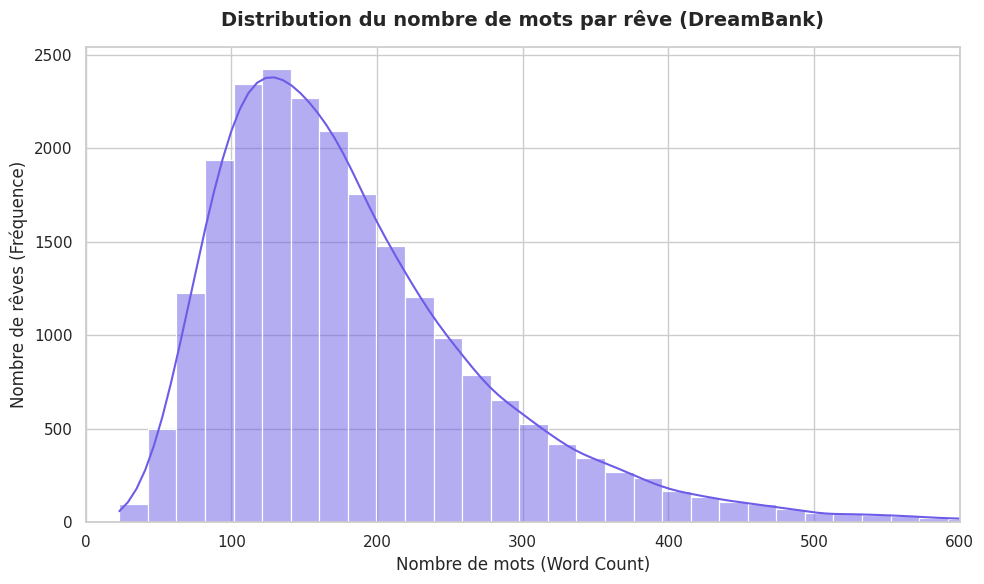

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate mock data resembling a text length log-normal distribution
np.random.seed(42)
mock_word_counts = np.random.lognormal(mean=5.1, sigma=0.5, size=22415)
# Clip or filter realistic limits (e.g., max 1500 words)
mock_word_counts = np.clip(mock_word_counts, 5, 1200)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histogram + KDE
sns.histplot(mock_word_counts, bins=60, kde=True, color='#6C5CE7', ax=ax, edgecolor='white')

ax.set_title("Distribution du nombre de mots par rêve (DreamBank)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Nombre de mots (Word Count)", fontsize=12)
ax.set_ylabel("Nombre de rêves (Fréquence)", fontsize=12)
ax.set_xlim(0, 600)  # Zooming into the most interesting part

plt.tight_layout()
plt.savefig("word_count_distribution.png", dpi=300)
print("Mock plot generated successfully")